In [1]:
from pathlib import Path
from ase.io import read
from ase import Atoms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

O objetivo deste Jupyter Notebook será o de analisar a composição do dataset utilizado pra produzir as bandas do modelo007, no qual utilizou-se alguns subsets e um filtro de força de 20 e $\text{eV}/\AA$.

<div align="center">

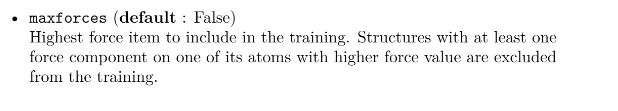

</div>

In [73]:
data = Path("/home/jvc/ZnO_database/data")

traininig = data / "dataset" / "01_LDA_dataset_filtered" / "train"
subsets_names = [
    "LDA_118_XSF",
    "LDA_214_XSF",
    "LDA_333_XSF",
    "LDA_normal_modes_3x3x3",
]

subsets: list[Path] = [data / f"subsets/{s}" for s in subsets_names]
xsf_dirs: list[Path] = [traininig, *subsets]
all_files: list[Path] = [file for d in xsf_dirs for file in sorted(d.glob("*.xsf"))]

In [74]:
atoms = [read(f) for f in all_files]

In [4]:

def get_force_df(atoms: list[Atoms], filenames: list[Path]) -> pd.DataFrame:

    dados_forcas = []

    for i, snapshot in enumerate(atoms):
        forces = snapshot.get_forces()

        for idx_atomo, vetor_forca in enumerate(forces):
            symbols: list[str] = snapshot.get_chemical_symbols()
            dados_forcas.append(
                { 'filename': filenames[i].name,                 # Número do snapshot (0, 1, 2...)
                'atom': symbols[idx_atomo],                 # Índice do átomo dentro do frame
                'fx': vetor_forca[0],
                'fy': vetor_forca[1],
                'fz': vetor_forca[2]}
            )

    df_forcas = pd.DataFrame(dados_forcas)
    return df_forcas     

In [5]:
forces = get_force_df(atoms=atoms, filenames=all_files)

In [6]:
forces["atomo_valido"] = (forces.iloc[:,2:].abs() <= 20).all(axis=1)

print("Amostra do Dataframe filtrando por força no átomo:\n")
display(forces.sample(10))

df_estruturas = forces.groupby("filename")[["atomo_valido"]].all().reset_index()
df_estruturas = df_estruturas.rename(columns={"atomo_valido":"estrutura_valida"})

print("Amostra do Dataframe filtrando por estrutura válida:\n")
display(df_estruturas)

Amostra do Dataframe filtrando por força no átomo:



,filename,atom,fx,fy,fz,atomo_valido
11580,0749-LDA-ZnO-3.20-1.51-222.xsf,Zn,0.000021,-0.000014,-27.584199,False
6545,0425-LDA-ZnO-3.00-1.77-311.xsf,Zn,-0.000224,-0.000133,31.479761,False
25039,1602-LDA-ZnO-2.88-1.51-113-0.04.xsf,O,0.192007,-24.374311,83.147203,False
88959,5840-LDA-ZnO-3.32-1.73-113-0.12.xsf,O,-20.551868,-7.105870,31.251632,False
31167,2001-LDA-ZnO-3.00-1.77-321-0.04.xsf,O,-30.626545,-32.793434,-29.428354,False
23000,1482-LDA-ZnO-3.52-1.54-331.xsf,Zn,-0.000161,0.000098,0.352636,True
66323,4311-LDA-ZnO-3.39-1.48-222-0.06.xsf,O,-4.469016,2.029712,51.221594,False
75357,4945-LDA-ZnO-2.94-1.64-212-0.12.xsf,Zn,-189.943465,-159.879431,12.073892,False
8388,0552-LDA-ZnO-3.07-1.73-213.xsf,Zn,-0.000014,-0.000007,20.570996,False
49602,3204-LDA-ZnO-2.88-1.57-213-0.06.xsf,O,40.953146,-41.530483,-0.915966,False


Amostra do Dataframe filtrando por estrutura válida:



,filename,estrutura_valida
0,0001-LDA-ZnO-2.88-1.44-111.xsf,False
1,0003-LDA-ZnO-2.88-1.44-113.xsf,False
2,0005-LDA-ZnO-2.88-1.44-212.xsf,False
3,0007-LDA-ZnO-2.88-1.44-221.xsf,False
4,0009-LDA-ZnO-2.88-1.44-311.xsf,False
...,...,...
5296,LDA-0238-ZnO-118-fa1.10-fc1.06-n0.040.out.xsf,False
5297,LDA-0239-ZnO-118-fa1.10-fc1.08-n0.000.out.xsf,True
5298,LDA-0240-ZnO-118-fa1.10-fc1.08-n0.040.out.xsf,False
5299,LDA-0241-ZnO-118-fa1.10-fc1.10-n0.000.out.xsf,True


In [7]:
count_estruturas = df_estruturas['estrutura_valida'].value_counts()
count_estruturas.index = ("Inválidas", "Válidas")

print(f"Contagem estruturas:\n{count_estruturas}\n")



Contagem estruturas:
Inválidas    4089
Válidas      1212
Name: count, dtype: int64



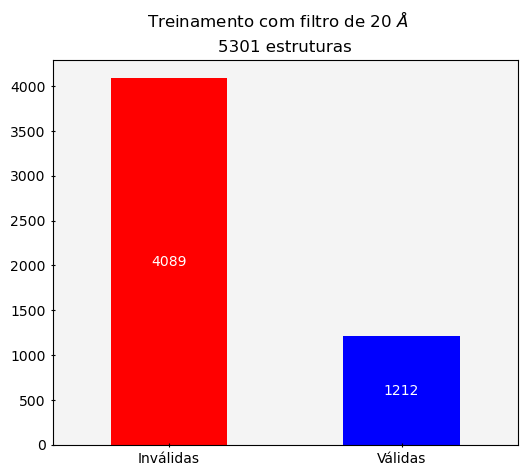

In [17]:
fig, ax = plt.subplots(figsize=(6,5))
fig.suptitle(r"Treinamento com filtro de 20 $\AA$")
ax.set_title(f"{df_estruturas.shape[0]} estruturas")
ax.set_facecolor("#f4f4f4")
count_estruturas.plot(kind='bar',ax=ax,rot=0, color=["red","blue"])
ax.bar_label(container=ax.containers[0], label_type='center', color='white')
ax.tick_params(direction='inout')
plt.show()

In [45]:
forces.sample(3)

,filename,atom,fx,fy,fz,atomo_valido
98528,LDA-0099-ZnO-118-fa0.98-fc1.00-n0.000.out.xsf,Zn,0.000000,-0.000000,6.220687,True
30656,1970-LDA-ZnO-3.00-1.70-221-0.04.xsf,Zn,-30.185993,18.662530,12.320779,False
50569,3271-LDA-ZnO-2.88-1.73-222-0.06.xsf,Zn,-23.971225,96.351597,75.918590,False


 - nomenclatura antiga e sem ruído -> `'0001-LDA-ZnO-2.88-1.44-111.xsf'`
 - nomenclatura antiga e com ruído -> `'2498-LDA-ZnO-3.26-1.61-112-0.04.xsf'`

 - nomenclatura nova sem ruído: `LDA-0215-ZnO-118-fa1.08-fc1.06-n0.000.out.xsf`
 - nomenclatura nova com ruído: `LDA-0150-ZnO-118-fa1.02-fc1.06-n0.040.out.xsf	`


In [51]:
filenames: list[str] = [f.name for f in all_files]

In [72]:
list(subsets[0].glob("*.xsf"))


[PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0127-ZnO-118-fa1.00-fc1.06-n0.000.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0044-ZnO-118-fa0.92-fc1.10-n0.040.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0140-ZnO-118-fa1.02-fc0.96-n0.040.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0021-ZnO-118-fa0.90-fc1.10-n0.000.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0040-ZnO-118-fa0.92-fc1.06-n0.040.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0057-ZnO-118-fa0.94-fc1.02-n0.000.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0193-ZnO-118-fa1.06-fc1.06-n0.000.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0067-ZnO-118-fa0.96-fc0.90-n0.000.out.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/subsets/LDA_118_XSF/LDA-0078-ZnO-118-fa0.96-fc1.00-n0.040.out.xsf'),
 PosixPath('/home/j

In [63]:
forces.sample(40)

,filename,atom,fx,fy,fz,atomo_valido
31693,2034-LDA-ZnO-3.07-1.51-213-0.04.xsf,Zn,22.297969,-14.600231,-51.401288,False
5493,0359-LDA-ZnO-3.00-1.61-222.xsf,Zn,0.000000,0.000000,-0.168639,True
32164,2064-LDA-ZnO-3.07-1.57-312-0.04.xsf,Zn,-6.171090,-8.949675,-59.128137,False
17020,1089-LDA-ZnO-3.32-1.64-312.xsf,Zn,0.000007,0.000000,1.458315,True
66761,4337-LDA-ZnO-3.39-1.54-222-0.06.xsf,Zn,-2.532888,2.996115,22.634786,False
101961,LDA-0215-ZnO-118-fa1.08-fc1.06-n0.000.out.xsf,Zn,0.000000,0.000000,0.027027,True
61543,4001-LDA-ZnO-3.20-1.77-312-0.06.xsf,O,-20.764115,-10.164132,-19.619670,False
14900,0946-LDA-ZnO-3.26-1.64-312.xsf,Zn,0.000077,0.000042,2.713827,True
90895,5977-LDA-ZnO-3.39-1.70-312-0.12.xsf,O,-2.164321,-5.580138,39.063844,False
29920,1922-LDA-ZnO-3.00-1.57-313-0.04.xsf,Zn,-7.365035,-54.707458,47.313235,False


---

## Normal Modes - Comparing

In [ ]:
def map_zno_bands(band_array):
    """
    Mapeia um array (X, 12) para os modos específicos do ZnO.
    Assume que as bandas estão em ordem crescente de energia.
    """
    return {
        "Acusticos": band_array[:, 0:3],   # Transversal e Longitudinal Acústico
        "E2_low":    band_array[:, 3:5],   # Vibração Zn (Plano xy)
        "B1_low":    band_array[:, 5],     # Silencioso (Eixo z)
        "TO_modes":  band_array[:, 6:8],   # E1(TO) e A1(TO)
        "B1_high":   band_array[:, 8],     # Silencioso (Eixo z)
        "E2_high":   band_array[:, 9:11],  # Vibração O (Plano xy)
        "LO_top":    band_array[:, 11]     # Geralmente A1(LO)
    }


def plot_in_ax(x, y, ax, **kwargs):
    """Plot in a specified ax with optional keyword arguments color and linestyle"""
    

    ax.plot(x, y, **kwargs)



def get_high_symmetry_points_and_labes(filename: str):
    """Lê o arquivo .bands do alamode

    Returns:
        - labels1 : list[str]   com pontos de alta simetria -> xtick labels
        - pontos  : list[float] com pontos de alta simetria -> xticks  
        
    """
    with open(filename, "r") as f:
        lines: list[str] = f.readlines()

    labels: list[str] = lines[0].strip().split()[1:]
    xticklabels = [r"$\Gamma$" if label == "G" else label for label in labels]

    xticks = np.array(lines[1].strip().split()[1:], dtype=float)    

    return xticklabels, xticks

In [ ]:
path_dft = "/home/jvc/ZnO_database/alamode_phonons/01_qe_finite_diff/LDA/bandas_backup/zno222_NA0.bands"
path_mlff = "/home/jvc/ZnO_database/alamode_phonons/03_mlff_aenetpytorch/LDA/model006/phonons/zno_lda_mlff.bands"

dft_data = np.loadtxt(path_dft,comments="#" )
mlff_data = np.loadtxt(path_mlff, comments="#")

x_dft = dft_data[:, 0]
bandas_dft = dft_data[:, 1:]

x_mlff = mlff_data[:, 0]
bandas_mlff = mlff_data[:, 1:]

dft_modes = map_zno_bands(bandas_dft)
mlff_modes = map_zno_bands(bandas_mlff)


xticklabels, xticks = get_high_symmetry_points_and_labes(path_dft) # They share the same

In [ ]:
def plot_panel_comparing_modes(kpoints: np.ndarray, bandas_dft: np.ndarray, bandas_mlff: np.ndarray, save=False, **kwargs):
    """
    Plotar individualmente as 12 bandas do Óxido de Zinco.
    """
    style_DFT = dict(color="black", ls='-', lw=2, label="DFT")
    style_MLFF = dict(color="red", ls="--", lw=2, label="MLFF")
    
    fig, axes = plt.subplots(figsize=(14,14),nrows=4, ncols=3, dpi=300, layout="constrained")
    fig.set_facecolor("#f4f4f4")
    fig.suptitle("Normal Modes of Zinc Oxide", fontsize=18)
    
    
    
    mode_names = [
        r"TA$_1$", r"TA$_2$", r"LA",
        r"E$_2^{\mathrm{low}}$ (1)", r"E$_2^{\mathrm{low}}$ (2)", r"B$_1^{\mathrm{low}}$",
        r"A$_1$", r"E$_1$ (1)", r"E$_1$ (2)",
        r"E$_2^{\mathrm{high}}$ (1)", r"E$_2^{\mathrm{high}}$ (2)", r"B$_1^{\mathrm{high}}$"
    ]

    # Assuming 'axes' is your flattened 1D array of the 12 subplots
    for i, ax in enumerate(axes.flatten()):
        if i in (0, 3, 6, 9, 12):
                ax.set_ylabel(r"Frequency cm$^{-1}$", size=14)
        
        ax.set_title(mode_names[i], fontsize=12, loc='left')
        ax.plot(kpoints, bandas_dft[:, i], **style_DFT)
        ax.plot(kpoints, bandas_mlff[:, i], **style_MLFF)
        ax.legend()
        ax.tick_params(direction="inout")

    
        for spine in ['left', 'right', 'top', 'bottom']:
            ax.spines[spine].set_linewidth(1.5)
        
        if kwargs is not None:
             ax.set_xticks(kwargs['xticks'])
             ax.set_xticklabels(kwargs['xticklabels'], size=12)

             for vline in kwargs['xticks']:
                  ax.axvline(vline, ls='--', color='gray', alpha=0.3, lw=0.5)
    
    if save:
         filename = input("Digite o nome do plot:\n")
         plt.savefig(filename)
    
    plt.show()
    return ax 

In [ ]:
plot_panel_comparing_modes(kpoints=x_dft, bandas_dft=bandas_dft, bandas_mlff=bandas_mlff, save=True, xticks=xticks, xticklabels=xticklabels)